<a href="https://colab.research.google.com/github/sarabdar/YOLOv26FinetuningDetectionSegmentation/blob/main/Yolo26_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "ultralytics>=8.4.0" supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: i

### DATASET Downloading

In [ ]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = YOUR_ROBOFLOW_API_KEY
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("roboflow-jvuqo")
project = workspace.project("basketball-player-detection-3-ycjdo")
version = project.version(18)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-player-detection-3-18 in yolov11:: 100%|██████████| 1313/1313 [00:00<00:00, 2434.72it/s]


### Training

In [ ]:
!yolo task=detect mode=train model=yolo26m.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/basketball-player-detection-3-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, h

### Inference

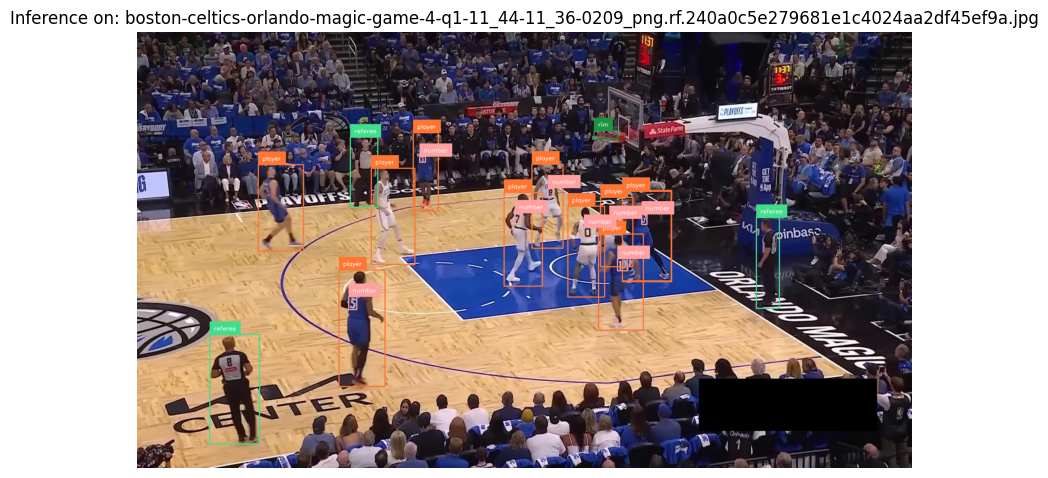

In [ ]:
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import supervision as sv
import os

# My Base directory
HOME = '/content'

model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

# Define the path to the test images
test_images_dir = f"{dataset.location}/test/images"

# Get a list of all image files in the test directory
image_files = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Randomly select one image from the dataset
if image_files:
    selected_image_path = random.choice(image_files)
else:
    raise ValueError(f"No image files found in {test_images_dir}")

# Load and run inference
image = Image.open(selected_image_path)
result = model.predict(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

# Annotate (visualize bounding boxes) the image
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image.copy(), detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

# Display the annotated image
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.title(f"Inference on: {os.path.basename(selected_image_path)}")
plt.axis("off")
plt.show()

# Lets do Segmentation now

In [ ]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = YOUR_API_KEY
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("car-damaged-detection-e66m0")
project = workspace.project("car-part-detection-with-damage-part")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Part-Detection-with-Damage-Part-2 in yolov11:: 100%|██████████| 2008/2008 [00:00<00:00, 2877.27it/s]


### Training the Model

In [ ]:
!yolo task=segment mode=train model=yolo26m-seg.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Part-Detection-with-Damage-Part-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0

### Inference

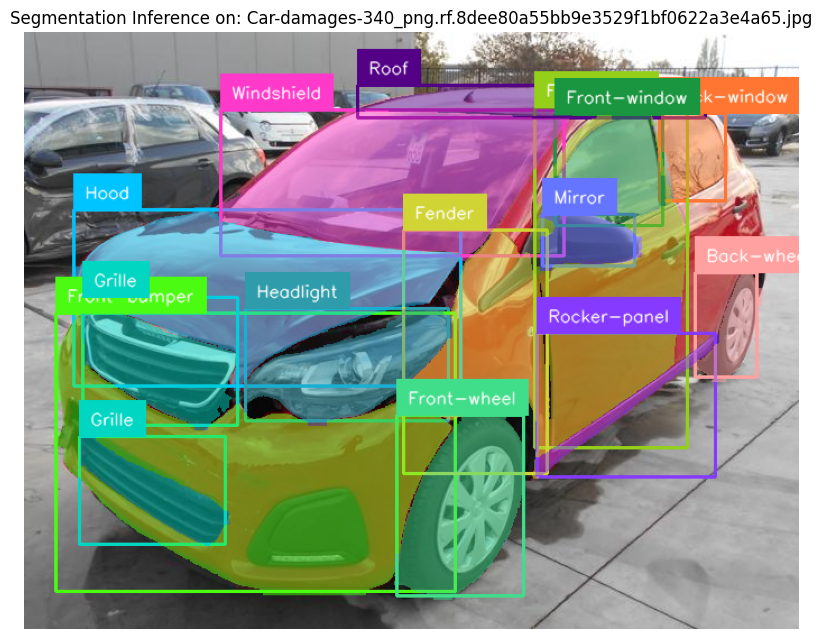

In [ ]:
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import supervision as sv
import os

# This is my base path cuz i am running a colab notebook
HOME = '/content'

model = YOLO(f'{HOME}/runs/segment/train/weights/best.pt')

# Define the path to the test images
test_images_dir = f"{dataset.location}/test/images"

# Get a list of all image files in the test directory
image_files = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Randomly select one image from the dataset
if image_files:
    selected_image_path = random.choice(image_files)
else:
    raise ValueError(f"No image files found in {test_images_dir}")

image = Image.open(selected_image_path)
result = model.predict(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

# Annotate (visualize bounding boxes and masks) the image
box_annotator = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = box_annotator.annotate(
    scene=image.copy(), detections=detections)
annotated_image = mask_annotator.annotate(
    scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

# Display the annotated image
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.title(f"Segmentation Inference on: {os.path.basename(selected_image_path)}")
plt.axis("off")
plt.show()